# Exploring Iceberg Tables with Fugue — Multi-Backend Demo

**Architecture:**
```
PyIceberg (load tables from Iceberg REST Catalog)
    |
    v
Arrow / Pandas DataFrames
    |
    v
Fugue %%fsql magic
    |
    ├── Pandas   (products — 10 rows, tiny dimension table)
    ├── DuckDB   (customers — 500 rows, OLAP analytics)
    ├── Spark    (orders — 100K rows, distributed joins)
    ├── Dask     (clickstream — 1M rows, parallel sessionization)
    └── Ray      (recommendations — 50K rows, parallel scoring)
```

Fugue lets you write one SQL dialect and swap execution backends. Each table below is queried
with the backend best suited to its size and workload pattern.

## Prerequisites
Run the Airflow DAG `Insert_Customer_Order_Data_To_Iceberg` first to populate all 5 tables.

## 1. Connect to Iceberg & Load All Tables

In [9]:
import time
from pyiceberg.catalog import load_catalog

timings = {}
_start = time.time()

# Connect to the Iceberg REST catalog
catalog = load_catalog(
    "rest",
    **{
        "uri": "http://iceberg-rest:8181",
        "s3.endpoint": "http://minio:9000",
        "s3.access-key-id": "minioadmin",
        "s3.secret-access-key": "minioadmin",
        "s3.region": "us-east-1",
    }
)

# List available tables
for ns in catalog.list_namespaces():
    tables = catalog.list_tables(ns[0])
    print(f"Namespace '{ns[0]}': {[t[1] for t in tables]}")

# Load all 5 tables as Pandas DataFrames via PyIceberg -> Arrow -> Pandas
products = catalog.load_table("ecommerce.products").scan().to_pandas()
customers = catalog.load_table("ecommerce.customers").scan().to_pandas()
orders = catalog.load_table("ecommerce.orders").scan().to_pandas()
clickstream = catalog.load_table("ecommerce.clickstream").scan().to_pandas()
recommendations = catalog.load_table("ecommerce.recommendations").scan().to_pandas()

timings["1. Load all tables"] = time.time() - _start
print(f"\nLoaded: products={len(products)}, customers={len(customers)}, "
      f"orders={len(orders)}, clickstream={len(clickstream)}, "
      f"recommendations={len(recommendations)}")
print(f"Done in {timings['1. Load all tables']:.3f}s")

Namespace 'ecommerce': ['clickstream', 'customers', 'orders', 'products', 'recommendations']

Loaded: products=10, customers=500, orders=100000, clickstream=1000000, recommendations=50000
Done in 3.279s


## 2. Setup Fugue SQL Magic

In [10]:
import fugue.api as fa

# %%fsql magic is auto-registered via fugue-jupyter startup script
# (installed during Docker image build with: fugue-jupyter install startup)
print("Fugue ready — %%fsql magic available")

Fugue ready — %%fsql magic available


## 3. Pandas Backend — Product Catalog Margin Analysis

**Why Pandas?** Only 10 rows. Pandas has zero startup overhead — no cluster, no JVM, no coordination. For tiny dimension tables, it's the fastest option.

In [11]:
%%fsql
SELECT
    product_id,
    product_name,
    category,
    price,
    cost,
    ROUND(price - cost, 2) AS margin,
    ROUND((price - cost) / price * 100, 1) AS margin_pct
FROM products
ORDER BY margin DESC
PRINT

,product_id:str,product_name:str,category:str,"price:decimal(4,2)","cost:decimal(4,2)","margin:decimal(5,2)",margin_pct:double
0,PROD-002,Mechanical Keyboard,Peripherals,89.99,35.00,54.99,61.1
1,PROD-008,Headphones,Audio,79.99,30.00,49.99,62.5
2,PROD-005,Webcam HD,Peripherals,59.99,22.00,37.99,63.3
3,PROD-003,USB-C Hub,Accessories,45.50,18.00,27.50,60.4
4,PROD-004,Monitor Stand,Furniture,34.99,14.00,20.99,60.0
5,PROD-001,Wireless Mouse,Peripherals,29.99,12.50,17.49,58.3
6,PROD-007,Desk Lamp,Furniture,24.99,9.00,15.99,64.0
7,PROD-006,Laptop Sleeve,Accessories,19.99,6.50,13.49,67.5
8,PROD-009,Mouse Pad,Accessories,12.99,3.50,9.49,73.1
9,PROD-010,Cable Organizer,Accessories,9.99,2.80,7.19,72.0


## 4. DuckDB Backend — Customer Segmentation Analytics

**Why DuckDB?** 500 rows with GROUP BY aggregations. DuckDB is an in-process OLAP engine optimized for analytical queries — faster than Pandas for aggregations, no cluster needed.

In [12]:
%%fsql duckdb
SELECT
    segment,
    region,
    COUNT(*) AS customer_count,
    MIN(signup_date) AS earliest_signup,
    MAX(signup_date) AS latest_signup
FROM customers
GROUP BY segment, region
ORDER BY customer_count DESC
PRINT

,segment:str,region:str,customer_count:long,earliest_signup:date,latest_signup:date
0,premium,APAC,39,2023-01-19,2023-12-27
1,premium,US-West,33,2023-01-06,2023-12-21
2,standard,US-Central,32,2023-01-03,2023-12-26
3,basic,EU-West,32,2023-01-14,2023-12-19
4,basic,APAC,30,2023-01-05,2023-12-28
5,premium,EU-East,30,2023-01-10,2023-12-24
6,basic,US-Central,30,2023-01-02,2023-12-28
7,basic,EU-East,30,2023-01-21,2023-12-14
8,premium,US-Central,27,2023-02-02,2023-11-10
9,standard,EU-West,27,2023-02-04,2023-12-24


## 5. Spark Backend — Order Enrichment with Multi-Table Joins

**Why Spark?** 100K orders joined against customers and products. Spark handles distributed joins efficiently. Fugue spins up a local SparkSession — same SQL, different engine.

In [13]:
%%fsql spark
SELECT
    c.segment,
    p.category,
    COUNT(*) AS total_orders,
    SUM(o.quantity) AS total_units,
    SUM(CAST(o.unit_price AS DOUBLE) * CAST(o.quantity AS DOUBLE)) AS total_revenue
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN products p ON o.product_id = p.product_id
WHERE o.status = 'completed'
GROUP BY c.segment, p.category
ORDER BY total_revenue DESC
PRINT

INFO:py4j.clientserver:Error while sending or receiving.
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/py4j/clientserver.py", line 503, in send_command
    self.socket.sendall(command.encode("utf-8"))
ConnectionResetError: [Errno 104] Connection reset by peer
INFO:py4j.clientserver:Closing down clientserver connection
INFO:root:Exception while sending command.
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/py4j/clientserver.py", line 503, in send_command
    self.socket.sendall(command.encode("utf-8"))
ConnectionResetError: [Errno 104] Connection reset by peer

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/py4j/clientse

,segment:str,category:str,total_orders:long,total_units:long,total_revenue:double
0,premium,Peripherals,6305,18856,1129881.44
1,basic,Peripherals,6184,18696,1107293.04
2,standard,Peripherals,5449,16207,981587.93
3,premium,Accessories,8368,25041,554176.31
4,basic,Accessories,8229,24728,546261.93
5,premium,Audio,2203,6585,526734.15
6,basic,Audio,2128,6460,516735.4
7,standard,Accessories,7341,21934,486159.5
8,standard,Audio,1858,5509,440664.91
9,premium,Furniture,4247,12820,384031.8


## 6. Dask Backend — Clickstream Sessionization

**Why Dask?** 1M event rows with per-session aggregation. Dask partitions the data across cores for embarrassingly parallel GROUP BY — no Spark overhead, pure Python parallelism.

In [14]:
%%fsql dask
SELECT
    session_id,
    customer_id,
    device,
    COUNT(*) AS events_in_session,
    COUNT(DISTINCT product_id) AS products_viewed,
    SUM(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS purchases,
    SUM(CASE WHEN event_type = 'add_to_cart' THEN 1 ELSE 0 END) AS add_to_carts
FROM clickstream
GROUP BY session_id, customer_id, device
TAKE 20 ROWS
PRINT

/opt/conda/lib/python3.11/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 45.72 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


,session_id:str,customer_id:str,device:str,events_in_session:long,products_viewed:long,purchases:long,add_to_carts:long
0,SESS-000001,CUST-0060,desktop,1,1,0,1
1,SESS-000001,CUST-0005,tablet,1,1,0,0
2,SESS-000001,CUST-0303,tablet,1,1,1,0
3,SESS-000001,CUST-0145,desktop,1,1,0,0
4,SESS-000001,CUST-0491,tablet,1,1,0,0
5,SESS-000001,CUST-0245,desktop,1,1,0,0
6,SESS-000001,CUST-0026,tablet,1,1,1,0
7,SESS-000001,CUST-0356,mobile,1,1,0,0
8,SESS-000001,CUST-0078,mobile,1,1,0,1
9,SESS-000001,CUST-0499,desktop,1,1,0,0


## 7. Ray Backend — Recommendation Scoring

**Why Ray?** 50K recommendation rows with filtering and joins. Ray excels at parallel compute tasks — here it filters high-confidence recommendations and enriches them with product names.

In [15]:
%%fsql ray
SELECT
    r.customer_id,
    p.product_name,
    p.category,
    r.score,
    r.reason
FROM recommendations r
JOIN products p ON r.product_id = p.product_id
WHERE r.score > 0.7
ORDER BY r.score DESC
TAKE 20 ROWS
PRINT

,customer_id:str,product_name:str,category:str,score:float,reason:str
0,CUST-0194,Monitor Stand,Furniture,1.0,browsing_history
1,CUST-0464,Cable Organizer,Accessories,1.0,similar_purchase
2,CUST-0425,Cable Organizer,Accessories,1.0,similar_purchase
3,CUST-0357,USB-C Hub,Accessories,1.0,frequently_bought_together
4,CUST-0091,Laptop Sleeve,Accessories,1.0,frequently_bought_together
5,CUST-0368,Desk Lamp,Furniture,1.0,browsing_history
6,CUST-0274,Laptop Sleeve,Accessories,1.0,browsing_history
7,CUST-0233,Mechanical Keyboard,Peripherals,1.0,frequently_bought_together
8,CUST-0172,Wireless Mouse,Peripherals,1.0,frequently_bought_together
9,CUST-0263,Monitor Stand,Furniture,1.0,trending


## 8. Backend Portability — Same Query, Different Engines

The real power of Fugue: write the query once, run it on any backend. Below we run the same revenue query on Pandas, DuckDB, and Spark to compare.

In [16]:
import fugue.api as fa

revenue_query = """
SELECT
    product_id,
    COUNT(*) AS order_count,
    SUM(quantity) AS total_units
FROM orders
WHERE status = 'completed'
GROUP BY product_id
ORDER BY total_units DESC
"""

for engine in [None, "duckdb", "spark"]:
    engine_name = engine or "pandas"
    _start = time.time()
    result = fa.fugue_sql(revenue_query, orders=orders, engine=engine)
    elapsed = time.time() - _start
    timings[f"8. Revenue query ({engine_name})"] = elapsed
    print(f"\n--- {engine_name.upper()} ({elapsed:.3f}s) ---")
    print(fa.as_pandas(result).head(5))


--- PANDAS (0.393s) ---
  product_id  order_count total_units
0   PROD-008         6189       18554
1   PROD-005         5985       18029
2   PROD-009         6019       18019
3   PROD-007         5993       17974
4   PROD-001         5981       17969

--- DUCKDB (0.258s) ---
  product_id  order_count total_units
0   PROD-008         6189       18554
1   PROD-005         5985       18029
2   PROD-009         6019       18019
3   PROD-007         5993       17974
4   PROD-001         5981       17969

--- SPARK (3.131s) ---


  product_id  order_count  total_units
0   PROD-008         6189        18554
1   PROD-005         5985        18029
2   PROD-009         6019        18019
3   PROD-007         5993        17974
4   PROD-001         5981        17969


## 9. Python + SQL Hybrid — Custom Transform with Fugue

Fugue lets you mix Python transforms with SQL. Define a Python function, then reference it in FugueSQL with the `TRANSFORM` keyword.

In [17]:
import pandas as pd

# schema: *, margin_tier:str
def classify_margin(df: pd.DataFrame) -> pd.DataFrame:
    """Classify products by margin tier based on margin percentage."""
    df = df.copy()
    margin_pct = (df["price"] - df["cost"]) / df["price"] * 100
    df["margin_tier"] = margin_pct.apply(
        lambda x: "high" if x >= 60 else ("medium" if x >= 50 else "low")
    )
    return df

In [18]:
%%fsql
transformed = TRANSFORM products USING classify_margin

SELECT product_name, category, price, cost, margin_tier
FROM transformed
ORDER BY price DESC
PRINT

,product_name:str,category:str,"price:decimal(4,2)","cost:decimal(4,2)",margin_tier:str
0,Mechanical Keyboard,Peripherals,89.99,35.00,high
1,Headphones,Audio,79.99,30.00,high
2,Webcam HD,Peripherals,59.99,22.00,high
3,USB-C Hub,Accessories,45.50,18.00,high
4,Monitor Stand,Furniture,34.99,14.00,medium
5,Wireless Mouse,Peripherals,29.99,12.50,medium
6,Desk Lamp,Furniture,24.99,9.00,high
7,Laptop Sleeve,Accessories,19.99,6.50,high
8,Mouse Pad,Accessories,12.99,3.50,high
9,Cable Organizer,Accessories,9.99,2.80,high


## 10. Visualization — Revenue by Category (from Spark result)

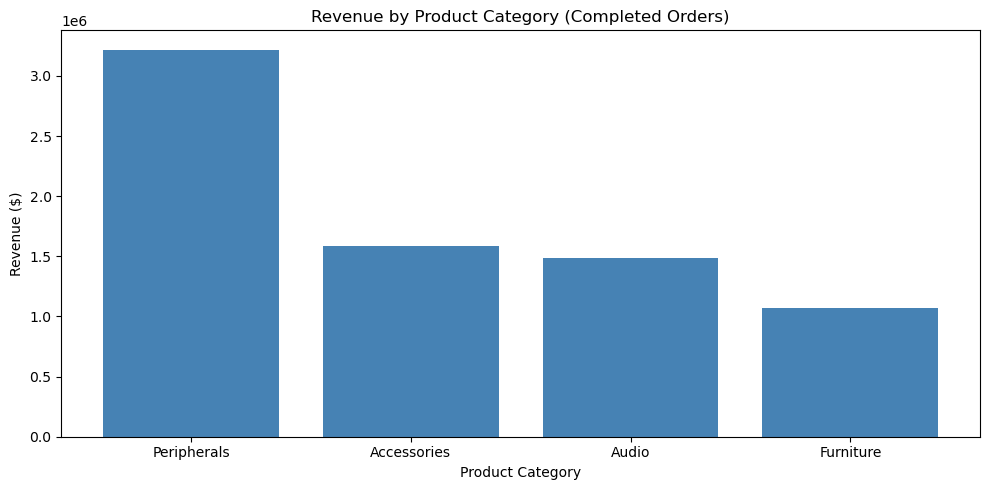

Done in 0.586s


In [19]:
import matplotlib.pyplot as plt

_start = time.time()

# Run revenue-by-category query via DuckDB for visualization
viz_result = fa.fugue_sql("""
SELECT
    p.category,
    SUM(CAST(o.unit_price AS DOUBLE) * CAST(o.quantity AS DOUBLE)) AS revenue
FROM orders o
JOIN products p ON o.product_id = p.product_id
WHERE o.status = 'completed'
GROUP BY p.category
ORDER BY revenue DESC
""", orders=orders, products=products, engine="duckdb")
viz_data = fa.as_pandas(viz_result)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(viz_data["category"], viz_data["revenue"], color="steelblue")
ax.set_xlabel("Product Category")
ax.set_ylabel("Revenue ($)")
ax.set_title("Revenue by Product Category (Completed Orders)")
plt.tight_layout()
plt.show()

timings["10. Visualization"] = time.time() - _start
print(f"Done in {timings['10. Visualization']:.3f}s")

## Summary

```
PyIceberg  →  Arrow/Pandas  →  Fugue %%fsql  →  [Pandas | DuckDB | Spark | Dask | Ray]  →  DataFrame
```

| Table | Rows | Backend | Use Case |
|-------|------|---------|----------|
| products | 10 | Pandas | Tiny lookup — zero overhead |
| customers | 500 | DuckDB | OLAP aggregations — fast in-process analytics |
| orders | 100K | Spark | Multi-table joins — distributed processing |
| clickstream | 1M | Dask | Parallel sessionization — Python-native parallelism |
| recommendations | 50K | Ray | Parallel scoring — compute-oriented parallelism |

**Key insight:** Fugue decouples your query logic from the execution engine. Write SQL once, choose the best backend for each workload.

## 11. Performance Summary

In [20]:
summary = pd.DataFrame([
    {"Step": k, "Time (s)": f"{v:.3f}"}
    for k, v in timings.items()
])
total = sum(timings.values())
summary.loc[len(summary)] = {"Step": "TOTAL", "Time (s)": f"{total:.3f}"}
summary

,Step,Time (s)
0,1. Load all tables,3.279
1,8. Revenue query (pandas),0.393
2,8. Revenue query (duckdb),0.258
3,8. Revenue query (spark),3.131
4,10. Visualization,0.586
5,TOTAL,7.646
